In [8]:
from google.colab import files
uploaded = files.upload()

Saving fantasia_individuals.csv to fantasia_individuals.csv
Saving hrv.py to hrv.py
Saving investigating_hrv_dataset.zip to investigating_hrv_dataset.zip


In [9]:
import os
import pandas as pd
import numpy as np
def calculate_HRV_metrics(file_in):
    df = pd.read_csv(file_in)
    df['time_next'] = df['time'].shift(-1)
    df['type_next'] = df['type'].shift(-1)
    df['rr'] = df['time_next'] - df['time']
    df['rr_type'] = df['type'] + df['type_next'].fillna('')
    df['rr_next'] = df['rr'].shift(-1)
    df['diff'] = df['rr_next'] - df['rr']
    df['diff_squared'] = df['diff'] ** 2
    df['rr_next_type'] = df['rr_type'].shift(-1)

    nn = df[df['rr_type'] == 'NN']
    n = len(nn)
    filename = os.path.basename(file_in)
    if n < 500:
        return {
            'filename': filename,
            'n': n,
            'mean_nn': None,
            'mean_bpm': None,
            'sdnn': None,
            'rmssd': None,
            'pnn20': None,
            'pnn50': None,
        }

    mean_nn = int(round(nn['rr'].mean()))
    mean_bpm = round((1000 / nn['rr'].mean()) * 60, 1)
    sdnn = round(nn['rr'].std(ddof=1), 1)
    nn_consec = df[(df['rr_type'] == 'NN') & (df['rr_next_type'] == 'NN')]
    rmssd = round(float(np.sqrt(nn_consec['diff_squared'].mean())), 1)
    pnn20 = round(float((np.abs(nn_consec['diff']) > 20).mean() * 100), 1)
    pnn50 = round(float((np.abs(nn_consec['diff']) > 50).mean() * 100), 1)

    return {
        'filename': filename,
        'n': n,
        'mean_nn': mean_nn,
        'mean_bpm': mean_bpm,
        'sdnn': sdnn,
        'rmssd': rmssd,
        'pnn20': pnn20,
        'pnn50': pnn50,
    }


In [10]:
import zipfile
with zipfile.ZipFile('investigating_hrv_dataset.zip', 'r') as z:
    z.extractall('dataset')

In [11]:
result = calculate_HRV_metrics('dataset/o01.csv')
print(result)
def process_HRV_files(file_list_in, file_out):
    results = []
    for file_path in file_list_in:
        try:
            metrics = calculate_HRV_metrics(file_path)
            results.append(metrics)
        except FileNotFoundError:
            print(f"Warning: File not found and will be skipped — {file_path}")
    if results:
              df_out = pd.DataFrame(results)
              df_out = df_out[['filename', 'mean_nn', 'mean_bpm', 'sdnn', 'rmssd', 'pnn20', 'pnn50']]
              df_out.to_csv(file_out, index=False)



{'filename': 'o01.csv', 'n': 7168, 'mean_nn': 1011, 'mean_bpm': np.float64(59.3), 'sdnn': 48.0, 'rmssd': 15.5, 'pnn20': 13.0, 'pnn50': 0.6}


In [12]:
import glob

file_list = sorted(glob.glob('dataset/*.csv'))
process_HRV_files(file_list, 'fantasia.csv')
print('Done!')

Done!


In [13]:
df = pd.read_csv('fantasia.csv')
print(df)

   filename  mean_nn  mean_bpm   sdnn  rmssd  pnn20  pnn50
0   o01.csv     1011      59.3   48.0   15.5   13.0    0.6
1   o02.csv     1062      56.5   33.7   15.0   12.6    0.4
2   o03.csv     1004      59.8   47.9   23.7   26.9    3.1
3   o04.csv     1163      51.6  116.3  118.1   40.3   12.5
4   o05.csv     1088      55.2   43.2   11.3    6.0    0.1
5   o06.csv     1168      51.4   23.9   19.9   24.6    0.7
6   o07.csv     1014      59.2   50.7   27.0   33.2    4.6
7   o08.csv      850      70.6   43.8   24.2   32.6    3.4
8   o09.csv     1483      40.4   94.4   66.5   67.9   35.1
9   o10.csv      880      68.2   57.3   20.9   27.7    2.0
10  y01.csv      830      72.3   93.0   91.9   75.3   47.0
11  y02.csv     1031      58.2   98.5   71.3   71.7   44.8
12  y03.csv      952      63.0   65.8   34.5   49.2   13.7
13  y04.csv     1314      45.7  122.6  105.8   85.2   66.9
14  y05.csv     1048      57.3  101.7   53.2   65.4   27.8
15  y06.csv     1020      58.8  101.6   55.9   63.4   29

In [14]:
hrv_df = pd.read_csv('fantasia.csv')
individuals = pd.read_csv('fantasia_individuals.csv')
hrv_df = hrv_df.merge(individuals, left_on='filename', right_on='file')
hrv_df = hrv_df.drop(columns='file')
print(hrv_df)

   filename  mean_nn  mean_bpm   sdnn  rmssd  pnn20  pnn50  age  group sex
0   o01.csv     1011      59.3   48.0   15.5   13.0    0.6   77    old   F
1   o02.csv     1062      56.5   33.7   15.0   12.6    0.4   73    old   F
2   o03.csv     1004      59.8   47.9   23.7   26.9    3.1   73    old   M
3   o04.csv     1163      51.6  116.3  118.1   40.3   12.5   81    old   M
4   o05.csv     1088      55.2   43.2   11.3    6.0    0.1   76    old   M
5   o06.csv     1168      51.4   23.9   19.9   24.6    0.7   74    old   F
6   o07.csv     1014      59.2   50.7   27.0   33.2    4.6   68    old   M
7   o08.csv      850      70.6   43.8   24.2   32.6    3.4   73    old   F
8   o09.csv     1483      40.4   94.4   66.5   67.9   35.1   71    old   M
9   o10.csv      880      68.2   57.3   20.9   27.7    2.0   71    old   F
10  y01.csv      830      72.3   93.0   91.9   75.3   47.0   23  young   F
11  y02.csv     1031      58.2   98.5   71.3   71.7   44.8   28  young   F
12  y03.csv      952     

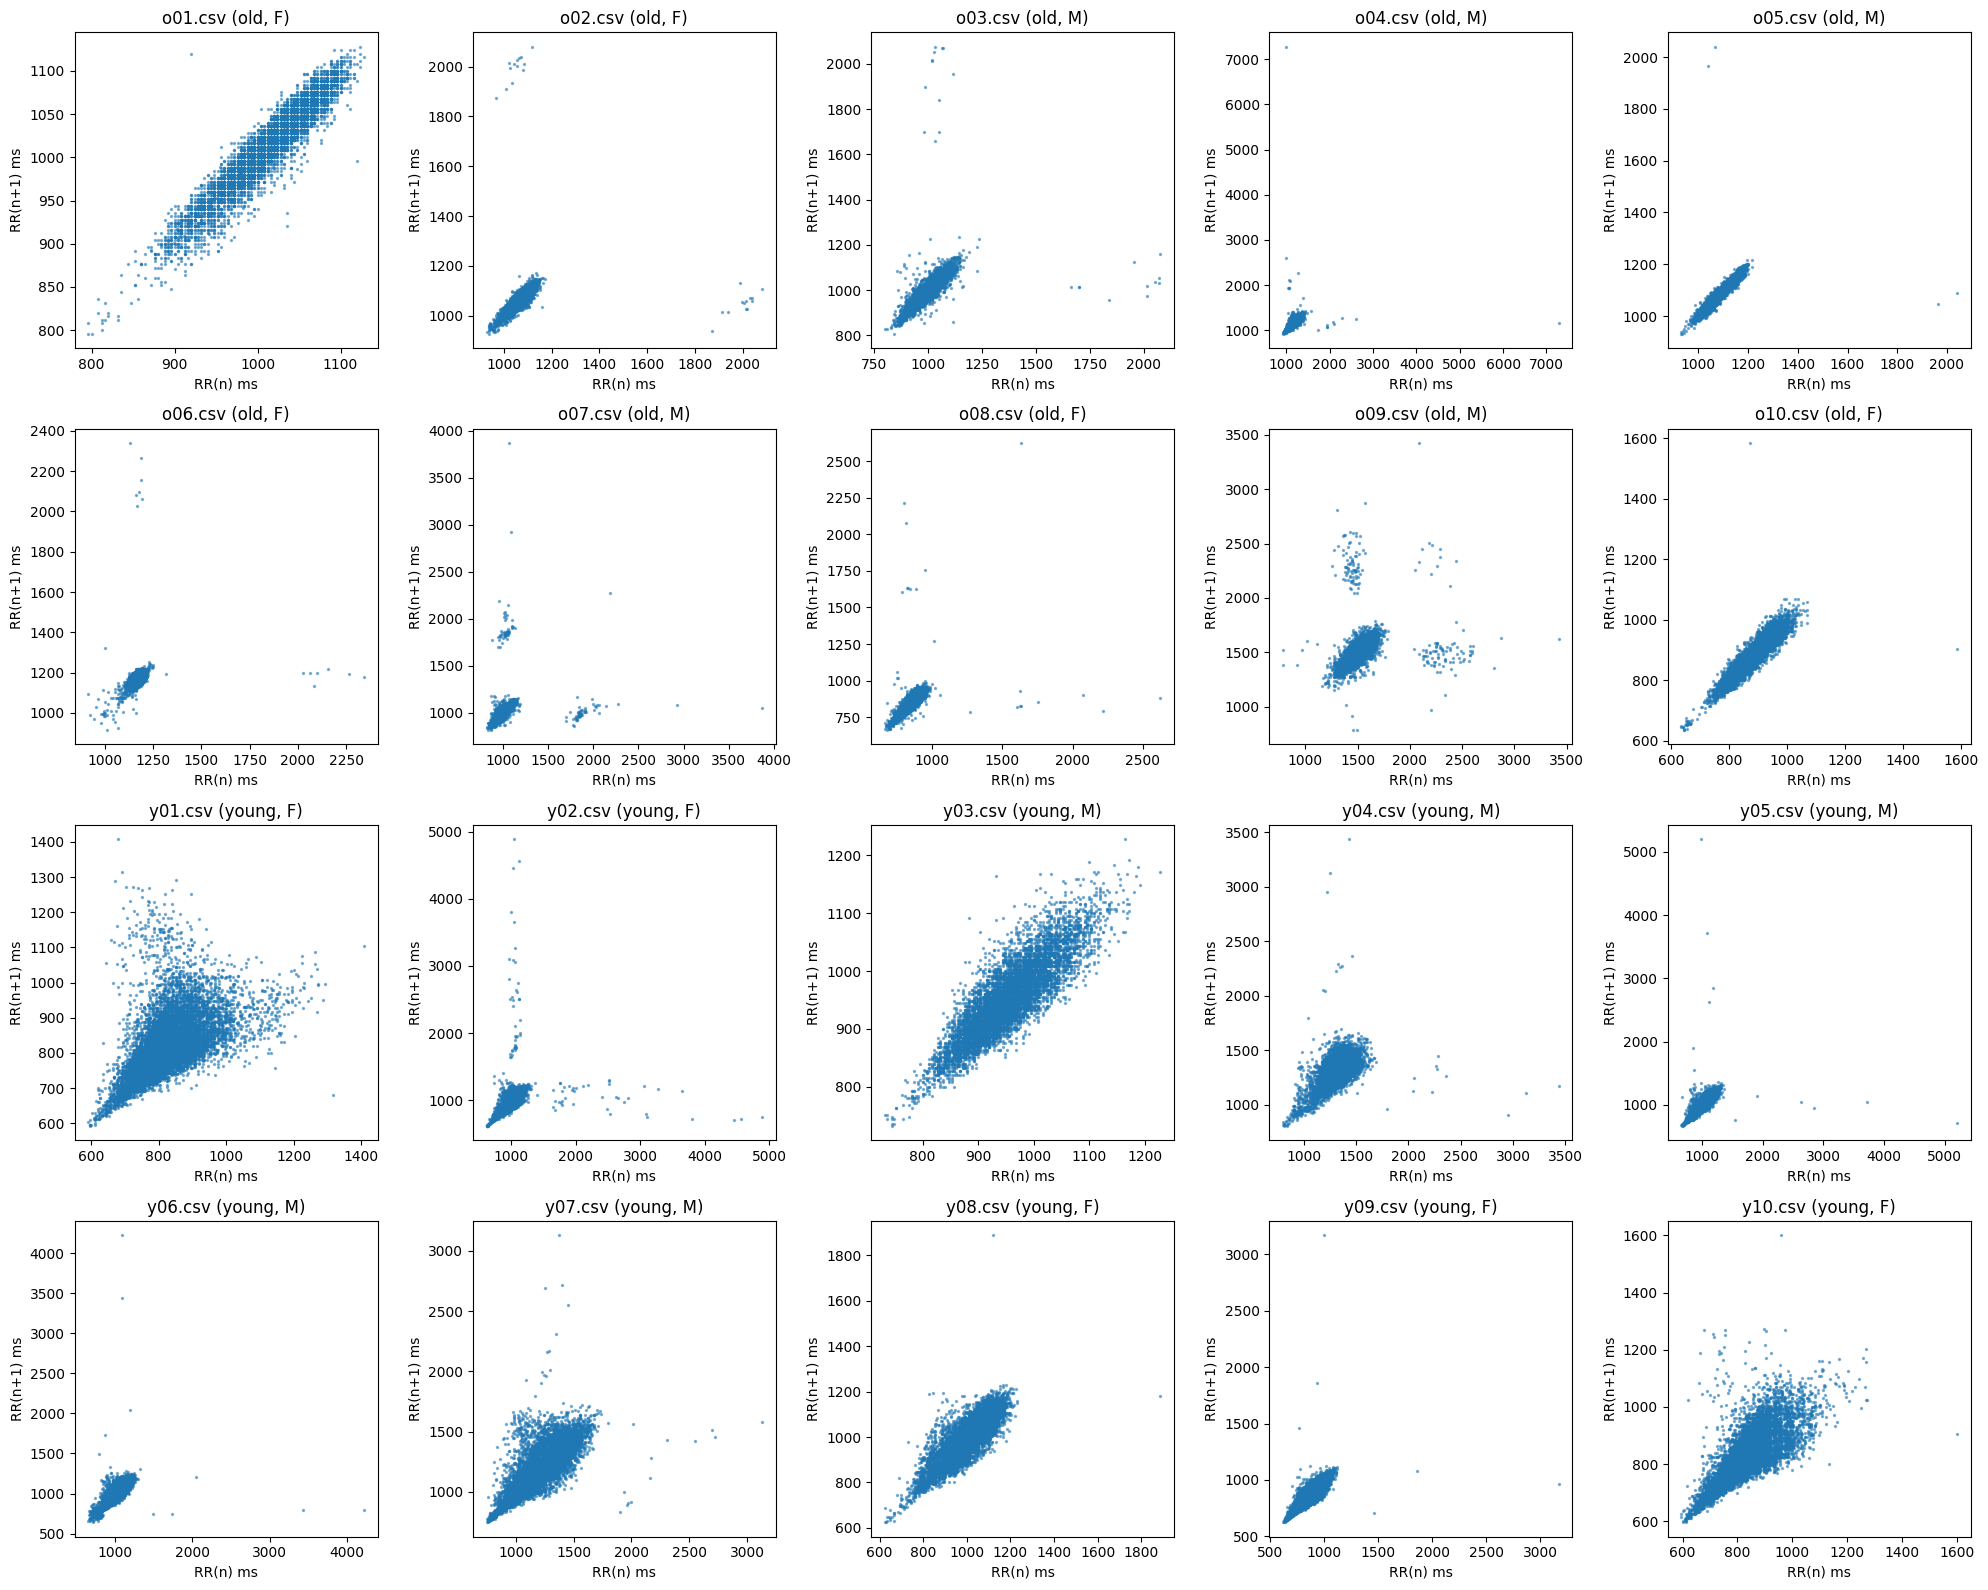

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, row in hrv_df.iterrows():
    df_ind = pd.read_csv(f"dataset/{row['filename']}")
    rr = df_ind[df_ind['type'] == 'N']['time'].diff().dropna()
    axes[i].scatter(rr[:-1], rr[1:], s=2, alpha=0.5)
    axes[i].set_title(f"{row['filename']} ({row['group']}, {row['sex']})")
    axes[i].set_xlabel('RR(n) ms')
    axes[i].set_ylabel('RR(n+1) ms')

plt.tight_layout()
plt.savefig('poincare_plots.png', dpi=150)
plt.show()

In [16]:
from scipy import stats

old = hrv_df[hrv_df['group'] == 'old']
young = hrv_df[hrv_df['group'] == 'young']

t_bpm, p_bpm = stats.ttest_ind(old['mean_bpm'], young['mean_bpm'])
t_rmssd, p_rmssd = stats.ttest_ind(old['rmssd'], young['rmssd'])

print(f"Mean BPM: t={t_bpm:.3f}, p={p_bpm:.3f}")
print(f"RMSSD:    t={t_rmssd:.3f}, p={p_rmssd:.3f}")

Mean BPM: t=-0.802, p=0.433
RMSSD:    t=-2.499, p=0.022


/tmp/ipykernel_418/3127790652.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([old['mean_bpm'], young['mean_bpm']], labels=['Old', 'Young'])
/tmp/ipykernel_418/3127790652.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([old['rmssd'], young['rmssd']], labels=['Old', 'Young'])


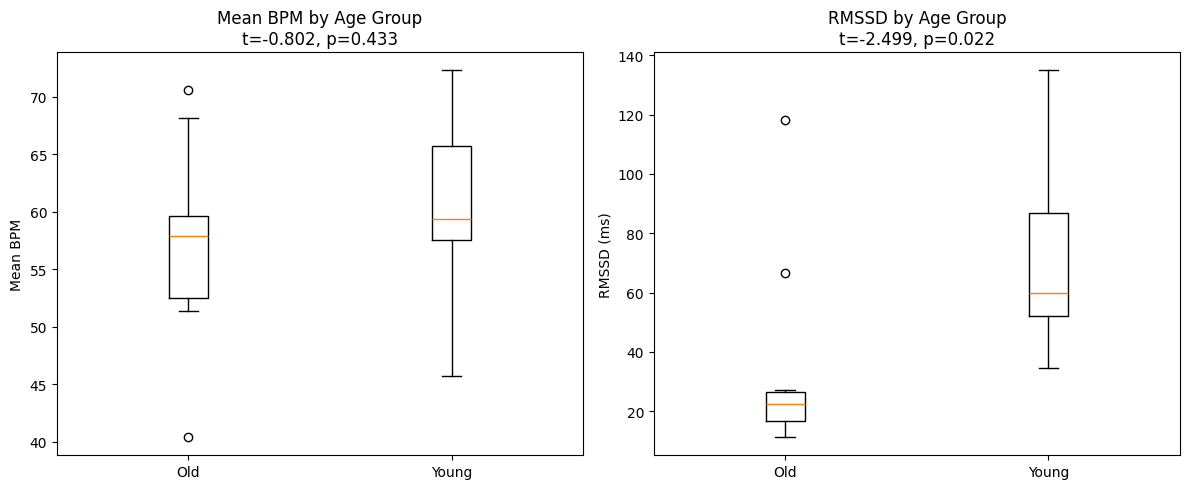

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([old['mean_bpm'], young['mean_bpm']], labels=['Old', 'Young'])
axes[0].set_title(f'Mean BPM by Age Group\nt={t_bpm:.3f}, p={p_bpm:.3f}')
axes[0].set_ylabel('Mean BPM')

axes[1].boxplot([old['rmssd'], young['rmssd']], labels=['Old', 'Young'])
axes[1].set_title(f'RMSSD by Age Group\nt={t_rmssd:.3f}, p={p_rmssd:.3f}')
axes[1].set_ylabel('RMSSD (ms)')

plt.tight_layout()
plt.savefig('ttest_figures.png', dpi=150)
plt.show()

2 T test were run to compare mean BPM and RMSSD between old group and young group. Both groups have similar heart rates because BPM showed no significant differences.
t=-0.802, p=0.433

HRV decrease with age. RMSSD shows much difference. Young group have more heart rate variability than old group.
t=-2.499, p=0.022

  6a. OBSERVATION ON POINCARÈ PLOT:

 It shows clear difference between old group and young group. Plots of old group are tight and narrow. Therefore no big difference in heaart beat intervals.Young group plots are big and more spreaded out comparatively meaning the heart beat interval is high. This matches t test result. scattered plots in young group is reflected in higher RMSSD values. BPM showed no significant difference. Plots of both group appear similar in position in the plotgraph.

  6b. T TEST APPLICABILITY EVALUATION:

T test sample size is small which is 10 people every group. Result is very precise and cannot be depended to make a final decision. Data in normal distribution is difficult to work on small sample. If sample size is small, better option would be U test.

  6c. ADDITIONAL USEFUL PLOTS:
Time series plot can be used to record sudden jump or drop in heart rates.
Histogram of rr can also be used to check if data is spread in normal or abnormal. Using these would remove noisy data early.

  6d. CURRENT RESEARCH ON HRV BY AGE AND GENDER:
Research says HRV decrease as people gets older. Because nervous system gets weak as people ages which is normal and which results in heart beat variation. Also, young men have high HRV than young women. Good heart health results in higher HRV.

REFERENCE: https://journals.physiology.org/doi/abs/10.1152/ajpregu.1996.271.4.R1078

    

In [18]:
from google.colab import files
files.download('hrv.py')
files.download('fantasia.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>